<a href="https://colab.research.google.com/github/raissaesteves/Fonte-de-Informa-o-e-Banco-de-Dados/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conheça o Colab

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

100%|██████████| 1.47k/1.47k [00:00<00:00, 914kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/raphaelmanayon/temperature-and-ice-cream-sales/versions/1


In [8]:
import pandas as pd
import os

# Assuming the CSV file is named 'Ice Cream Sales - temperatures.csv' inside the downloaded directory
csv_file_path = os.path.join(path, 'Ice Cream Sales - temperatures.csv')

df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head(10))

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
5,43,15.88
6,44,19.07
7,44,19.57
8,45,21.62
9,45,22.34


### Performing Linear Regression

First, I'll prepare the data by defining the independent variable (Temperature) and the dependent variable (Ice Cream Profits). Then, I'll split the data into training and testing sets to evaluate the model's performance on unseen data. Finally, I'll train a linear regression model.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define independent (X) and dependent (y) variables
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully.")
print(f"Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


SyntaxError: invalid decimal literal (1435448947.py, line 23)

### Model Evaluation and Visualization

Now, let's evaluate the trained model using the test set and visualize the regression line against the actual data points.

Mean Squared Error (MSE): 5.29
R-squared (R2): 0.98


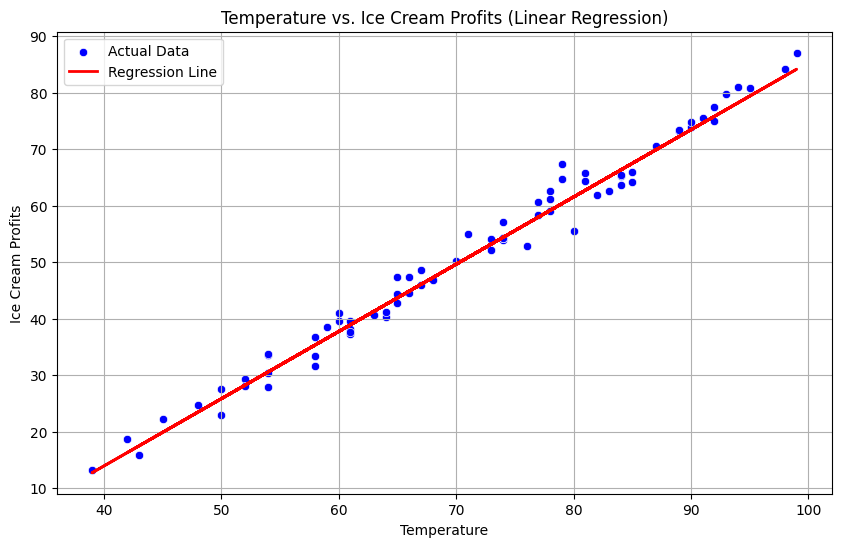

In [18]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize the results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Temperature'], y=y_test, color='blue', label='Actual Data')
plt.plot(X_test['Temperature'], y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Temperature vs. Ice Cream Profits (Linear Regression)')
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Profits')
plt.legend()
plt.grid(True)
plt.show()